# In-house 5'UTR PARADE vs BODA ResNet1D small HPO analysis

Analyze the completed in-house FivePrime fine-tuning sweep in `src/finetune/learning_curve/inhouse_utr5_parade_resnet_small_hpo_jun2026/combined`.

Key question: this run varied barcode-count training thresholds (`1+`, `2+`, `3+`) with `train_size=full`. It does **not** contain true sample-count downsampling levels such as 512, 1024, 2048, etc. The threshold plots below are therefore barcode-threshold curves, not full downsampling learning curves.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

def find_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents, Path("/home/minhang/synBio_AL/boda2_EU")]
    for candidate in candidates:
        if (candidate / "src/finetune/learning_curve").exists() and (candidate / "tutorials").exists():
            return candidate
    raise FileNotFoundError("Could not locate boda2_EU repo root from current working directory.")

REPO_ROOT = find_repo_root()
OUT_ROOT = REPO_ROOT / "src/finetune/learning_curve/inhouse_utr5_parade_resnet_small_hpo_jun2026"
COMBINED = OUT_ROOT / "combined"

# Main knob for the analysis cells below. Supported aliases include:
# "pearson", "pearson_r", "r", "cod_r2", "cod", "mse", "mse_loss", "loss", "spearman".
METRIC = "pearson"
DEFAULT_TOP_N = 25

assert COMBINED.exists(), f"Missing combined output directory: {COMBINED}"
COMBINED

PosixPath('/home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/inhouse_utr5_parade_resnet_small_hpo_jun2026/combined')

In [2]:
summary_raw = pd.read_csv(COMBINED / "model_comparison_summary.csv")
epoch_raw = pd.read_csv(COMBINED / "per_epoch_diagnostics.csv")
planned_raw = pd.read_csv(COMBINED / "planned_finetune_specs.csv")
split_summary_raw = pd.read_csv(COMBINED / "split_membership_summary.csv")

with open(COMBINED / "run_manifest.json") as handle:
    manifest = json.load(handle)

def prefer_non_nested_sources(df: pd.DataFrame) -> pd.DataFrame:
    if "source_job_dir" not in df.columns:
        return df.copy()
    out = df.copy()
    out["_nested_source"] = out["source_job_dir"].astype(str).str.contains("/runs/", regex=False)
    return out.sort_values("_nested_source").drop(columns="_nested_source")

SUMMARY_KEY = [
    "model_label",
    "model_family",
    "split",
    "cell_head",
    "train_threshold",
    "train_size",
    "run_seed",
    "unfreeze_scope",
    "head_lr",
    "backbone_lr",
    "freeze_backbone_epochs",
    "weight_decay",
]
EPOCH_KEY = [
    "model_label",
    "model_family",
    "epoch",
    "split",
    "cell_head",
    "train_threshold",
    "train_size",
    "run_seed",
    "unfreeze_scope",
    "head_lr",
    "backbone_lr",
    "freeze_backbone_epochs",
    "weight_decay",
]

summary = prefer_non_nested_sources(summary_raw).drop_duplicates(SUMMARY_KEY).reset_index(drop=True)
epoch = prefer_non_nested_sources(epoch_raw).drop_duplicates(EPOCH_KEY).reset_index(drop=True)
planned = planned_raw.drop_duplicates(["tag"]).reset_index(drop=True)
split_summary = split_summary_raw.drop(columns=["source_job_dir"], errors="ignore").drop_duplicates().reset_index(drop=True)

summary["is_finetuned"] = summary["model_label"].astype(str).str.startswith("finetuned__")
summary["config_label"] = (
    summary["model_family"].astype(str)
    + " | thr=" + summary["train_threshold"].astype(str)
    + " | head=" + summary["cell_head"].astype(str)
    + " | scope=" + summary["unfreeze_scope"].fillna("pretrained").astype(str)
)

display(Markdown("### Loaded outputs"))
display(pd.DataFrame([
    {"table": "model_comparison_summary", "raw_rows": len(summary_raw), "clean_rows": len(summary)},
    {"table": "per_epoch_diagnostics", "raw_rows": len(epoch_raw), "clean_rows": len(epoch)},
    {"table": "planned_finetune_specs", "raw_rows": len(planned_raw), "clean_rows": len(planned)},
    {"table": "split_membership_summary", "raw_rows": len(split_summary_raw), "clean_rows": len(split_summary)},
]))

### Loaded outputs

,table,raw_rows,clean_rows
0,model_comparison_summary,720,330
1,per_epoch_diagnostics,14432,7216
2,planned_finetune_specs,90,90
3,split_membership_summary,120,6


In [3]:
args = manifest.get("args", {})
train_sizes = sorted(summary["train_size"].astype(str).unique())
has_sample_downsampling = len(train_sizes) > 1 or train_sizes != ["full"]

overview = pd.DataFrame([
    {"field": "model families", "value": ", ".join(sorted(summary["model_family"].dropna().astype(str).unique()))},
    {"field": "train thresholds", "value": ", ".join(map(str, sorted(summary["train_threshold"].dropna().astype(int).unique())))},
    {"field": "train sizes", "value": ", ".join(train_sizes)},
    {"field": "cell heads", "value": ", ".join(sorted(summary["cell_head"].dropna().astype(str).unique()))},
    {"field": "unfreeze scopes", "value": ", ".join(sorted(summary.loc[summary["is_finetuned"], "unfreeze_scope"].dropna().astype(str).unique()))},
    {"field": "heldout_min_barcodes", "value": args.get("heldout_min_barcodes")},
    {"field": "heldout_frac_within_hq", "value": args.get("heldout_frac_within_hq")},
    {"field": "heldout_val_frac", "value": args.get("heldout_val_frac")},
    {"field": "planned fine-tune configs", "value": len(planned)},
])

display(Markdown("### Run overview"))
display(overview)

if has_sample_downsampling:
    display(Markdown("**Downsampling status:** sample-count downsampling is present in this run."))
else:
    display(Markdown(
        "**Downsampling status:** this run used `train_size=full` only. "
        "The curves below are barcode-threshold curves (`1+`, `2+`, `3+`), not true sample-count learning curves. "
        "For a true downsampling curve, rerun with multiple `TRAIN_SIZES`, for example `TRAIN_SIZES=\"512 1024 2048 full\"`."
    ))

### Run overview

,field,value
0,model families,"boda_resnet1d, parade"
1,train thresholds,"1, 2, 3"
2,train sizes,full
3,cell heads,"c1, c17, c2, c4, c6"
4,unfreeze scopes,"full, head_only, last_stage_plus_head"
5,heldout_min_barcodes,8
6,heldout_frac_within_hq,0.2
7,heldout_val_frac,0.2
8,planned fine-tune configs,90


**Downsampling status:** this run used `train_size=full` only. The curves below are barcode-threshold curves (`1+`, `2+`, `3+`), not true sample-count learning curves. For a true downsampling curve, rerun with multiple `TRAIN_SIZES`, for example `TRAIN_SIZES="512 1024 2048 full"`.

In [4]:
display(Markdown("### Split summary"))
split_view = split_summary.sort_values(["split", "train_threshold"], na_position="first")
display(split_view.round(4))

eligible_train = split_summary.loc[split_summary["split"].eq("eligible_train_pool")].copy()
if not eligible_train.empty:
    display(Markdown("Training pool sizes by barcode threshold."))
    display(eligible_train[["train_threshold", "n", "n_high_quality_rows", "target_mean", "target_std", "barcode_mean", "barcode_median"]].round(4))

### Split summary

,split,train_threshold,heldout_min_barcodes,heldout_frac_within_hq,n_high_quality_rows,n,target_mean,target_std,barcode_mean,barcode_median
3,eligible_train_pool,1.0,8,0.2,1438,7972,2.5778,0.6497,5.1331,4.0
4,eligible_train_pool,2.0,8,0.2,1438,6693,2.5842,0.5797,5.9229,5.0
5,eligible_train_pool,3.0,8,0.2,1438,5402,2.5824,0.5424,6.8604,5.0
0,test,NaN,8,0.2,287,287,2.5641,0.4596,11.2822,10.0
1,train_pool,NaN,8,0.2,1438,7972,2.5778,0.6497,5.1331,4.0
2,val,NaN,8,0.2,72,72,2.5419,0.4077,10.6250,9.5


Training pool sizes by barcode threshold.

,train_threshold,n,n_high_quality_rows,target_mean,target_std,barcode_mean,barcode_median
3,1.0,7972,1438,2.5778,0.6497,5.1331,4.0
4,2.0,6693,1438,2.5842,0.5797,5.9229,5.0
5,3.0,5402,1438,2.5824,0.5424,6.8604,5.0


In [5]:
# Metric-aware analysis helpers.
# Change METRIC above or pass a metric alias directly to any function below.

METRIC_ALIASES = {
    "spearman": "spearman",
    "spearman_r": "spearman",
    "rank_r": "spearman",
    "pearson": "pearson",
    "pearson_r": "pearson",
    "r": "pearson",
    "cod": "cod_r2",
    "cod_r2": "cod_r2",
    "r2_cod": "cod_r2",
    "mse": "mse",
    "mse_loss": "mse",
    "loss": "loss_standardized",
    "standardized_loss": "loss_standardized",
    "loss_standardized": "loss_standardized",
    "rmse": "rmse",
    "mae": "mae",
}
METRIC_LABELS = {
    "spearman": "Spearman R",
    "pearson": "Pearson R",
    "cod_r2": "COD R2",
    "mse": "MSE loss",
    "loss_standardized": "standardized MSE loss",
    "rmse": "RMSE",
    "mae": "MAE",
}
LOWER_IS_BETTER = {"rmse", "mae", "mse", "loss_standardized"}
REPORT_METRICS = ["spearman", "pearson", "cod_r2", "mse", "rmse", "loss_standardized"]
MATCH_COLS = [
    "model_label",
    "model_family",
    "cell_head",
    "train_threshold",
    "train_size",
    "run_seed",
    "unfreeze_scope",
    "head_lr",
    "backbone_lr",
    "freeze_backbone_epochs",
    "weight_decay",
]


def metric_column(metric: str) -> str:
    key = str(metric).strip().lower().replace(" ", "_").replace("-", "_")
    column = METRIC_ALIASES.get(key, key)
    if column not in summary.columns:
        valid = ", ".join(sorted(set(METRIC_ALIASES) | set(REPORT_METRICS)))
        raise ValueError(f"Unknown metric {metric!r}. Try one of: {valid}")
    return column


def metric_label(metric: str) -> str:
    column = metric_column(metric)
    return METRIC_LABELS.get(column, column.replace("_", " "))


def ascending_for(metric: str) -> bool:
    return metric_column(metric) in LOWER_IS_BETTER


def epoch_metric_column(metric: str) -> str:
    column = metric_column(metric)
    candidate = f"val_{column}"
    if candidate in epoch.columns:
        return candidate
    if column == "loss_standardized" and "val_loss_standardized" in epoch.columns:
        return "val_loss_standardized"
    if column in epoch.columns:
        return column
    raise ValueError(f"No per-epoch metric column available for {metric!r}.")


def metric_columns_with_suffix(suffix: str) -> list[str]:
    return [f"{m}_{suffix}" for m in REPORT_METRICS if f"{m}_{suffix}" in summary.columns or m in summary.columns]


def rank_models(metric: str = METRIC, split: str = "val", top_n: int | None = DEFAULT_TOP_N) -> pd.DataFrame:
    column = metric_column(metric)
    rows = summary.loc[summary["is_finetuned"] & summary["split"].eq(split)].copy()
    rows = rows.sort_values(column, ascending=ascending_for(column))
    if top_n is not None:
        rows = rows.head(top_n)
    cols = [
        "model_family",
        "train_threshold",
        "train_size",
        "cell_head",
        "unfreeze_scope",
        "actual_train_size",
        "best_epoch",
        *REPORT_METRICS,
        "model_label",
    ]
    return rows[[col for col in cols if col in rows.columns]].reset_index(drop=True)


def top_validation_with_test(metric: str = METRIC, top_n: int = DEFAULT_TOP_N) -> pd.DataFrame:
    column = metric_column(metric)
    val = summary.loc[summary["is_finetuned"] & summary["split"].eq("val")].copy()
    test = summary.loc[summary["is_finetuned"] & summary["split"].eq("test")].copy()
    val = val.sort_values(column, ascending=ascending_for(column)).head(top_n)
    merged = val.merge(
        test[[*MATCH_COLS, *[m for m in REPORT_METRICS if m in test.columns]]],
        on=MATCH_COLS,
        how="left",
        suffixes=("_val", "_test"),
    )
    keep = [
        "model_family",
        "train_threshold",
        "train_size",
        "cell_head",
        "unfreeze_scope",
        "actual_train_size",
        "best_epoch",
        *[f"{m}_val" for m in REPORT_METRICS if f"{m}_val" in merged.columns],
        *[f"{m}_test" for m in REPORT_METRICS if f"{m}_test" in merged.columns],
        "model_label",
    ]
    return merged[[col for col in keep if col in merged.columns]].reset_index(drop=True)


def show_top_configs(metric: str = METRIC, top_n: int = DEFAULT_TOP_N) -> pd.DataFrame:
    display(Markdown(f"### Top validation configs by `{metric_label(metric)}` with matched test metrics"))
    table = top_validation_with_test(metric, top_n=top_n)
    display(table.round(5))
    return table


def compare_metrics(metrics: list[str] | tuple[str, ...] = ("pearson", "cod_r2", "mse_loss"), top_n: int = 10) -> dict[str, pd.DataFrame]:
    out = {}
    for metric in metrics:
        out[metric_column(metric)] = show_top_configs(metric, top_n=top_n)
    return out


show_top_configs(METRIC, top_n=DEFAULT_TOP_N)

### Top validation configs by `Pearson R` with matched test metrics

,model_family,train_threshold,train_size,cell_head,unfreeze_scope,actual_train_size,best_epoch,spearman_val,pearson_val,cod_r2_val,mse_val,rmse_val,loss_standardized_val,spearman_test,pearson_test,cod_r2_test,mse_test,rmse_test,loss_standardized_test,model_label
0,boda_resnet1d,3,full,c4,full,5402.0,116.0,0.53605,0.53741,0.23328,0.12565,0.35447,0.42706,0.53942,0.51642,0.24264,0.15941,0.39926,0.54180,finetuned__boda_resnet1d__seed17__thr3__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
1,boda_resnet1d,2,full,c4,full,6693.0,71.0,0.51839,0.52186,0.23761,0.12494,0.35347,0.37183,0.56749,0.54174,0.28609,0.15027,0.38764,0.44720,finetuned__boda_resnet1d__seed17__thr2__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
2,boda_resnet1d,3,full,c17,full,5402.0,109.0,0.52261,0.51104,0.18129,0.13417,0.36630,0.45601,0.54021,0.51764,0.24397,0.15913,0.39891,0.54084,finetuned__boda_resnet1d__seed17__thr3__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
3,boda_resnet1d,2,full,c17,full,6693.0,86.0,0.50042,0.51006,0.20081,0.13097,0.36190,0.38978,0.56492,0.53884,0.27220,0.15319,0.39139,0.45590,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
4,boda_resnet1d,2,full,c2,full,6693.0,119.0,0.51605,0.50960,0.15641,0.13825,0.37182,0.41144,0.54238,0.50907,0.21311,0.16563,0.40697,0.49292,finetuned__boda_resnet1d__seed17__thr2__nfull__headc2__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
5,boda_resnet1d,2,full,c6,full,6693.0,100.0,0.53524,0.50457,0.14526,0.14008,0.37427,0.41687,0.56422,0.53623,0.25669,0.15645,0.39554,0.46561,finetuned__boda_resnet1d__seed17__thr2__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
6,boda_resnet1d,3,full,c6,full,5402.0,118.0,0.52341,0.50027,0.14815,0.13960,0.37363,0.47447,0.55090,0.52671,0.25720,0.15635,0.39541,0.53138,finetuned__boda_resnet1d__seed17__thr3__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
7,boda_resnet1d,2,full,c1,full,6693.0,100.0,0.53444,0.49152,0.14206,0.14060,0.37497,0.41844,0.56408,0.53759,0.26261,0.15521,0.39397,0.46191,finetuned__boda_resnet1d__seed17__thr2__nfull__headc1__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
8,boda_resnet1d,3,full,c2,full,5402.0,119.0,0.49141,0.48994,0.13012,0.14256,0.37757,0.48451,0.53196,0.50136,0.21745,0.16471,0.40585,0.55981,finetuned__boda_resnet1d__seed17__thr3__nfull__headc2__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
9,boda_resnet1d,2,full,c17,last_stage_plus_head,6693.0,119.0,0.47900,0.48895,0.18251,0.13397,0.36602,0.39871,0.54513,0.52663,0.27136,0.15337,0.39162,0.45643,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__last_stage_plus_head__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04


,model_family,train_threshold,train_size,cell_head,unfreeze_scope,actual_train_size,best_epoch,spearman_val,pearson_val,cod_r2_val,mse_val,rmse_val,loss_standardized_val,spearman_test,pearson_test,cod_r2_test,mse_test,rmse_test,loss_standardized_test,model_label
0,boda_resnet1d,3,full,c4,full,5402.0,116.0,0.536047,0.537413,0.233277,0.125652,0.354475,0.427056,0.539423,0.516422,0.242641,0.159412,0.399264,0.541795,finetuned__boda_resnet1d__seed17__thr3__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
1,boda_resnet1d,2,full,c4,full,6693.0,71.0,0.518393,0.521863,0.237610,0.124942,0.353471,0.371834,0.567487,0.541741,0.286091,0.150266,0.387642,0.447200,finetuned__boda_resnet1d__seed17__thr2__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
2,boda_resnet1d,3,full,c17,full,5402.0,109.0,0.522606,0.511041,0.181287,0.134173,0.366296,0.456014,0.540206,0.517639,0.243973,0.159131,0.398913,0.540842,finetuned__boda_resnet1d__seed17__thr3__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
3,boda_resnet1d,2,full,c17,full,6693.0,86.0,0.500418,0.510059,0.200809,0.130973,0.361902,0.389782,0.564923,0.538836,0.272203,0.153190,0.391394,0.455900,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
4,boda_resnet1d,2,full,c2,full,6693.0,119.0,0.516046,0.509601,0.156411,0.138249,0.371819,0.411436,0.542376,0.509068,0.213105,0.165629,0.406975,0.492919,finetuned__boda_resnet1d__seed17__thr2__nfull__headc2__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
5,boda_resnet1d,2,full,c6,full,6693.0,100.0,0.535243,0.504574,0.145261,0.140077,0.374268,0.416874,0.564220,0.536229,0.256694,0.156454,0.395543,0.465615,finetuned__boda_resnet1d__seed17__thr2__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
6,boda_resnet1d,3,full,c6,full,5402.0,118.0,0.523410,0.500268,0.148151,0.139603,0.373635,0.474470,0.550899,0.526712,0.257196,0.156348,0.395409,0.531383,finetuned__boda_resnet1d__seed17__thr3__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
7,boda_resnet1d,2,full,c1,full,6693.0,100.0,0.534440,0.491517,0.142056,0.140602,0.374969,0.418437,0.564075,0.537592,0.262607,0.155209,0.393966,0.461910,finetuned__boda_resnet1d__seed17__thr2__nfull__headc1__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
8,boda_resnet1d,3,full,c2,full,5402.0,119.0,0.491414,0.489943,0.130118,0.142558,0.377569,0.484515,0.531961,0.501364,0.217455,0.164713,0.405849,0.559813,finetuned__boda_resnet1d__seed17__thr3__nfull__headc2__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
9,boda_resnet1d,2,full,c17,last_stage_plus_head,6693.0,119.0,0.479002,0.488946,0.182507,0.133973,0.366023,0.398709,0.545128,0.526633,0.271358,0.153367,0.391622,0.456429,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__last_stage_plus_head__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04


### Best-by-threshold curve selected on val `Pearson R`

,model_family,train_threshold,actual_train_size,cell_head,unfreeze_scope,pearson_val,pearson_test,best_epoch
0,boda_resnet1d,3,5402.0,c4,full,0.53741,0.51642,116.0
1,boda_resnet1d,2,6693.0,c4,full,0.52186,0.54174,71.0
2,boda_resnet1d,1,7972.0,c4,full,0.47039,0.51577,46.0
3,parade,3,5402.0,c6,full,0.41624,0.51278,50.0
4,parade,2,6693.0,c6,full,0.45232,0.56306,119.0
5,parade,1,7972.0,c2,full,0.40536,0.50286,51.0


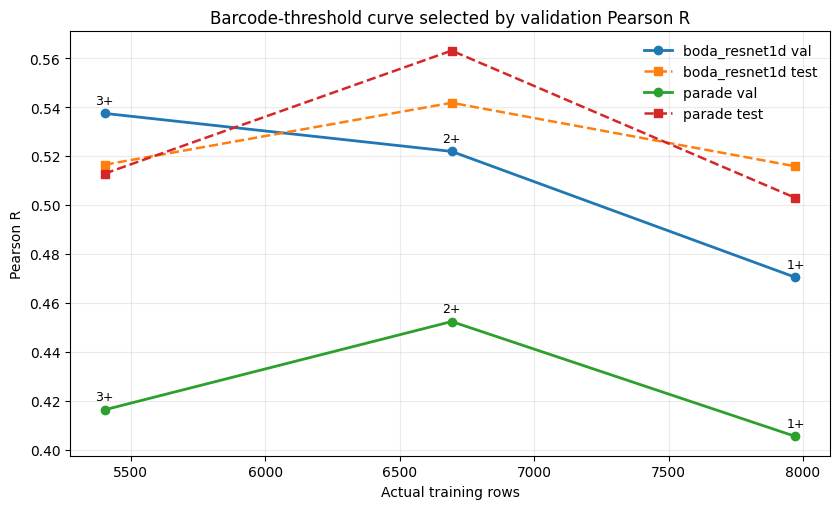

In [6]:
def best_threshold_curve(metric: str = METRIC, selection_split: str = "val") -> pd.DataFrame:
    column = metric_column(metric)
    selected = summary.loc[summary["is_finetuned"] & summary["split"].eq(selection_split)].copy()
    selected = selected.sort_values(column, ascending=ascending_for(column))
    best = selected.groupby(["model_family", "train_threshold"], observed=True, group_keys=False).head(1)
    test = summary.loc[summary["is_finetuned"] & summary["split"].eq("test")].copy()
    merged = best.merge(
        test[[*MATCH_COLS, *[m for m in REPORT_METRICS if m in test.columns]]],
        on=MATCH_COLS,
        how="left",
        suffixes=("_val", "_test"),
    )
    return merged.sort_values(["model_family", "actual_train_size", "train_threshold"]).reset_index(drop=True)


def show_threshold_curve(metric: str = METRIC, selection_split: str = "val") -> pd.DataFrame:
    column = metric_column(metric)
    curve = best_threshold_curve(column, selection_split=selection_split)
    display(Markdown(f"### Best-by-threshold curve selected on {selection_split} `{metric_label(column)}`"))
    display(curve[[
        "model_family",
        "train_threshold",
        "actual_train_size",
        "cell_head",
        "unfreeze_scope",
        f"{column}_val",
        f"{column}_test",
        "best_epoch",
    ]].round(5))
    return curve


def plot_threshold_curve(metric: str = METRIC, selection_split: str = "val") -> pd.DataFrame:
    column = metric_column(metric)
    label = metric_label(column)
    curve = show_threshold_curve(column, selection_split=selection_split)

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for family, group in curve.groupby("model_family", observed=True):
        group = group.sort_values("actual_train_size")
        ax.plot(group["actual_train_size"], group[f"{column}_val"], marker="o", linewidth=2, label=f"{family} val")
        ax.plot(group["actual_train_size"], group[f"{column}_test"], marker="s", linestyle="--", linewidth=1.8, label=f"{family} test")
        for _, row in group.iterrows():
            ax.annotate(f"{int(row['train_threshold'])}+", (row["actual_train_size"], row[f"{column}_val"]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)

    ax.set_xlabel("Actual training rows")
    ax.set_ylabel(label)
    ax.set_title(f"Barcode-threshold curve selected by validation {label}")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    return curve


curve = plot_threshold_curve(METRIC)

### Pretrained baseline references on validation `Pearson R`

,model_family,cell_head,best_baseline_pearson,model_label,mean_baseline_pearson
0,parade,c17,0.19344,pretrained__parade__headc17,0.15877
1,boda_resnet1d,c17,0.17043,pretrained__boda_resnet1d__headc17,0.13812


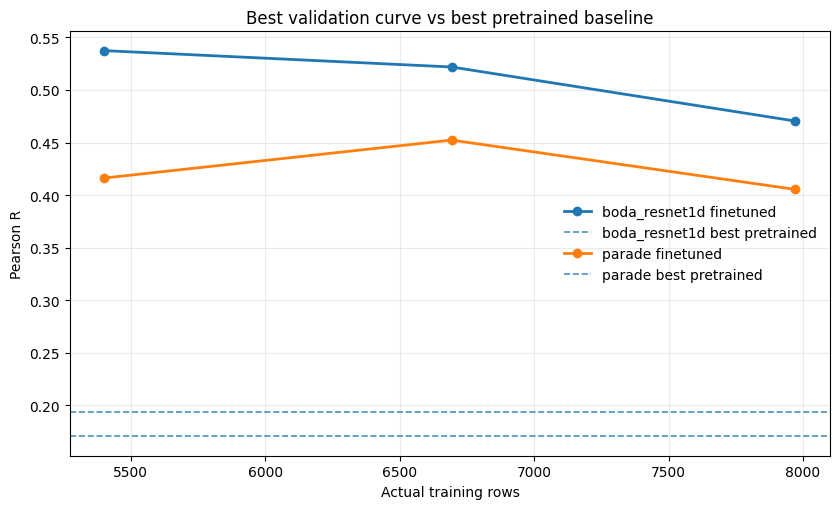

In [7]:
def baseline_reference(metric: str = METRIC, split: str = "val") -> pd.DataFrame:
    column = metric_column(metric)
    base = summary.loc[~summary["is_finetuned"] & summary["split"].eq(split)].copy()
    if base.empty:
        return base
    best = base.sort_values(column, ascending=ascending_for(column)).groupby("model_family", observed=True, group_keys=False).head(1)
    mean = base.groupby("model_family", observed=True)[column].mean().rename(f"mean_baseline_{column}").reset_index()
    return best[["model_family", "cell_head", column, "model_label"]].rename(columns={column: f"best_baseline_{column}"}).merge(mean, on="model_family", how="left")


def plot_baseline_curve(metric: str = METRIC, selection_split: str = "val") -> tuple[pd.DataFrame, pd.DataFrame]:
    column = metric_column(metric)
    label = metric_label(column)
    curve = best_threshold_curve(column, selection_split=selection_split)
    baseline = baseline_reference(column, "val")

    display(Markdown(f"### Pretrained baseline references on validation `{label}`"))
    display(baseline.round(5))

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    for family, group in curve.groupby("model_family", observed=True):
        group = group.sort_values("actual_train_size")
        ax.plot(group["actual_train_size"], group[f"{column}_val"], marker="o", linewidth=2, label=f"{family} finetuned")
        ref = baseline.loc[baseline["model_family"].eq(family)]
        if not ref.empty:
            ax.axhline(ref[f"best_baseline_{column}"].iloc[0], linestyle="--", linewidth=1.2, alpha=0.8, label=f"{family} best pretrained")

    ax.set_xlabel("Actual training rows")
    ax.set_ylabel(label)
    ax.set_title("Best validation curve vs best pretrained baseline")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    return curve, baseline


curve, baseline = plot_baseline_curve(METRIC)

In [8]:
def metric_matrix(metric: str = METRIC, split: str = "val", model_family: str = "boda_resnet1d", threshold: int = 1) -> pd.DataFrame:
    column = metric_column(metric)
    rows = summary.loc[
        summary["is_finetuned"]
        & summary["split"].eq(split)
        & summary["model_family"].eq(model_family)
        & summary["train_threshold"].eq(threshold)
    ].copy()
    agg = "min" if ascending_for(column) else "max"
    return rows.pivot_table(index="cell_head", columns="unfreeze_scope", values=column, aggfunc=agg).sort_index()


def show_metric_matrices(metric: str = METRIC, split: str = "val") -> dict[tuple[str, int], pd.DataFrame]:
    column = metric_column(metric)
    display(Markdown(f"### Cell-head x unfreeze-scope {split} tables for `{metric_label(column)}`"))
    matrices = {}
    for family in sorted(summary.loc[summary["is_finetuned"], "model_family"].dropna().unique()):
        for threshold in sorted(summary["train_threshold"].dropna().astype(int).unique()):
            table = metric_matrix(column, split, family, threshold)
            matrices[(family, threshold)] = table
            display(Markdown(f"**{family}, threshold {threshold}+**"))
            display(table.round(5))
    return matrices


matrices = show_metric_matrices(METRIC)

### Cell-head x unfreeze-scope val tables for `Pearson R`

**boda_resnet1d, threshold 1+**

unfreeze_scope,full,head_only,last_stage_plus_head
cell_head,,,
c1,0.44377,0.31507,0.40631
c17,0.46627,0.32771,0.40388
c2,0.43720,0.27664,0.40518
c4,0.47039,0.33609,0.40097
c6,0.46209,0.30522,0.41613


**boda_resnet1d, threshold 2+**

unfreeze_scope,full,head_only,last_stage_plus_head
cell_head,,,
c1,0.49152,0.30859,0.44672
c17,0.51006,0.34125,0.48895
c2,0.50960,0.30752,0.46472
c4,0.52186,0.33758,0.43908
c6,0.50457,0.32571,0.45657


...

unfreeze_scope,full,head_only,last_stage_plus_head
cell_head,,,
c1,0.40286,0.07379,0.29440
c17,0.39813,0.13930,0.30789
c2,0.40536,0.08123,0.31906
c4,0.40032,0.07546,0.27403
c6,0.39569,0.07565,0.30428


**parade, threshold 2+**

unfreeze_scope,full,head_only,last_stage_plus_head
cell_head,,,
c1,0.40833,0.07442,0.29538
c17,0.45230,0.07755,0.30902
c2,0.41037,0.13557,0.31725
c4,0.40801,0.07837,0.28466
c6,0.45232,0.13817,0.26927


**parade, threshold 3+**

unfreeze_scope,full,head_only,last_stage_plus_head
cell_head,,,
c1,0.41385,0.07844,0.25994
c17,0.40548,0.08352,0.27337
c2,0.40137,0.08499,0.27458
c4,0.40754,0.08518,0.26632
c6,0.41624,0.13605,0.26827


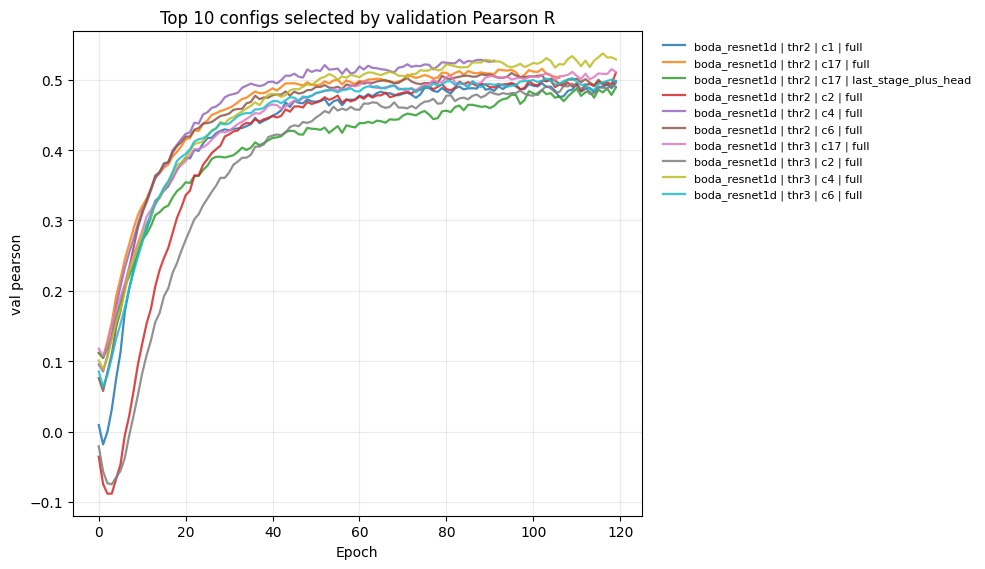

,model_family,train_threshold,cell_head,unfreeze_scope,pearson,best_epoch,model_label
0,boda_resnet1d,3,c4,full,0.53741,116.0,finetuned__boda_resnet1d__seed17__thr3__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
1,boda_resnet1d,2,c4,full,0.52186,71.0,finetuned__boda_resnet1d__seed17__thr2__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
2,boda_resnet1d,3,c17,full,0.51104,109.0,finetuned__boda_resnet1d__seed17__thr3__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
3,boda_resnet1d,2,c17,full,0.51006,86.0,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
4,boda_resnet1d,2,c2,full,0.50960,119.0,finetuned__boda_resnet1d__seed17__thr2__nfull__headc2__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
5,boda_resnet1d,2,c6,full,0.50457,100.0,finetuned__boda_resnet1d__seed17__thr2__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
6,boda_resnet1d,3,c6,full,0.50027,118.0,finetuned__boda_resnet1d__seed17__thr3__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
7,boda_resnet1d,2,c1,full,0.49152,100.0,finetuned__boda_resnet1d__seed17__thr2__nfull__headc1__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
8,boda_resnet1d,3,c2,full,0.48994,119.0,finetuned__boda_resnet1d__seed17__thr3__nfull__headc2__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
9,boda_resnet1d,2,c17,last_stage_plus_head,0.48895,119.0,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__last_stage_plus_head__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04


In [9]:
def plot_top_epoch_traces(selection_metric: str = METRIC, trace_metric: str | None = None, top_n: int = 10) -> pd.DataFrame:
    selection_column = metric_column(selection_metric)
    trace_column = epoch_metric_column(trace_metric or selection_column)
    top = summary.loc[summary["is_finetuned"] & summary["split"].eq("val")].copy()
    top = top.sort_values(selection_column, ascending=ascending_for(selection_column)).head(top_n)
    labels = top.set_index("model_label")[["model_family", "train_threshold", "cell_head", "unfreeze_scope"]].copy()
    labels["short_label"] = (
        labels["model_family"].astype(str)
        + " | thr" + labels["train_threshold"].astype(int).astype(str)
        + " | " + labels["cell_head"].astype(str)
        + " | " + labels["unfreeze_scope"].astype(str)
    )
    traces = epoch.loc[epoch["model_label"].isin(top["model_label"])].copy()
    traces = traces.merge(labels[["short_label"]], left_on="model_label", right_index=True, how="left")

    fig, ax = plt.subplots(figsize=(10, 5.8))
    for label, group in traces.groupby("short_label", observed=True):
        group = group.sort_values("epoch")
        ax.plot(group["epoch"], group[trace_column], linewidth=1.6, alpha=0.85, label=label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(trace_column.replace("_", " "))
    ax.set_title(f"Top {top_n} configs selected by validation {metric_label(selection_column)}")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    keep = ["model_family", "train_threshold", "cell_head", "unfreeze_scope", selection_column, "best_epoch", "model_label"]
    return top[[col for col in keep if col in top.columns]].reset_index(drop=True)


display(plot_top_epoch_traces(METRIC, top_n=10).round(5))

In [10]:
WRITE_CLEAN_TABLES = False

if WRITE_CLEAN_TABLES:
    analysis_dir = COMBINED / "analysis_tables"
    analysis_dir.mkdir(exist_ok=True)
    summary.to_csv(analysis_dir / "model_comparison_summary_clean.csv", index=False)
    epoch.to_csv(analysis_dir / "per_epoch_diagnostics_clean.csv", index=False)
    for metric in ("pearson", "cod_r2", "mse_loss"):
        column = metric_column(metric)
        top_validation_with_test(column, top_n=1000).to_csv(analysis_dir / f"top_validation_with_test_by_{column}.csv", index=False)
        best_threshold_curve(column).to_csv(analysis_dir / f"best_threshold_curve_by_{column}.csv", index=False)
    print(f"Wrote clean analysis tables to {analysis_dir}")

## Sample-count downsampling follow-up

This section analyzes the completed follow-up run in `inhouse_utr5_parade_resnet_downsample_top_configs_jun2026`. Unlike the first HPO, this run includes multiple `TRAIN_SIZES`, so the plots below are true sample-count learning curves. The functions reuse the notebook-wide `METRIC` aliases, so you can call them with `"pearson"`, `"cod_r2"`, `"mse_loss"`, `"spearman"`, etc.

In [11]:
DOWNSAMPLE_OUT_ROOT = REPO_ROOT / "src/finetune/learning_curve/inhouse_utr5_parade_resnet_downsample_top_configs_jun2026"
DOWNSAMPLE_COMBINED = DOWNSAMPLE_OUT_ROOT / "combined"

assert DOWNSAMPLE_COMBINED.exists(), f"Missing downsampling combined output directory: {DOWNSAMPLE_COMBINED}"


def train_size_label(value) -> str:
    if pd.isna(value):
        return "NA"
    text = str(value).strip()
    if text.lower() == "full":
        return "full"
    try:
        numeric = float(text)
        if numeric.is_integer():
            return str(int(numeric))
    except ValueError:
        pass
    return text


def add_train_size_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["train_size_label"] = out["train_size"].map(train_size_label)
    numeric = pd.to_numeric(out["train_size_label"].replace({"full": np.nan, "NA": np.nan}), errors="coerce")
    actual = pd.to_numeric(out.get("actual_train_size", pd.Series(np.nan, index=out.index)), errors="coerce")
    out["train_size_numeric"] = numeric.fillna(actual)
    out["train_size_order"] = np.where(out["train_size_label"].eq("full"), actual, numeric)
    return out


def load_combined_analysis(combined_dir: Path) -> dict[str, object]:
    summary_raw = pd.read_csv(combined_dir / "model_comparison_summary.csv")
    epoch_raw = pd.read_csv(combined_dir / "per_epoch_diagnostics.csv")
    planned_raw = pd.read_csv(combined_dir / "planned_finetune_specs.csv")
    split_summary_raw = pd.read_csv(combined_dir / "split_membership_summary.csv")

    manifest_path = combined_dir / "run_manifest.json"
    manifest_obj = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}

    clean_summary = prefer_non_nested_sources(summary_raw).drop_duplicates(SUMMARY_KEY).reset_index(drop=True)
    clean_epoch = prefer_non_nested_sources(epoch_raw).drop_duplicates(EPOCH_KEY).reset_index(drop=True)
    clean_planned = planned_raw.drop_duplicates(["tag"]).reset_index(drop=True)
    clean_split = split_summary_raw.drop(columns=["source_job_dir"], errors="ignore").drop_duplicates().reset_index(drop=True)

    clean_summary["is_finetuned"] = clean_summary["model_label"].astype(str).str.startswith("finetuned__")
    clean_summary = add_train_size_columns(clean_summary)
    clean_epoch = add_train_size_columns(clean_epoch)
    clean_planned = add_train_size_columns(clean_planned)

    return {
        "summary_raw": summary_raw,
        "epoch_raw": epoch_raw,
        "planned_raw": planned_raw,
        "split_summary_raw": split_summary_raw,
        "summary": clean_summary,
        "epoch": clean_epoch,
        "planned": clean_planned,
        "split_summary": clean_split,
        "manifest": manifest_obj,
    }


down = load_combined_analysis(DOWNSAMPLE_COMBINED)
down_summary = down["summary"]
down_epoch = down["epoch"]
down_planned = down["planned"]
down_split_summary = down["split_summary"]
down_manifest = down["manifest"]

train_size_order = down_planned[["train_size_label", "train_size_order"]].drop_duplicates().sort_values("train_size_order")
train_size_order

,train_size_label,train_size_order
0,512,512.0
1,1024,1024.0
2,2048,2048.0
3,4096,4096.0
4,full,NaN


In [12]:
display(Markdown("### Downsampling run overview"))

down_overview = pd.DataFrame([
    {"table": "model_comparison_summary", "raw_rows": len(down["summary_raw"]), "clean_rows": len(down_summary)},
    {"table": "per_epoch_diagnostics", "raw_rows": len(down["epoch_raw"]), "clean_rows": len(down_epoch)},
    {"table": "planned_finetune_specs", "raw_rows": len(down["planned_raw"]), "clean_rows": len(down_planned)},
    {"table": "split_membership_summary", "raw_rows": len(down["split_summary_raw"]), "clean_rows": len(down_split_summary)},
])
display(down_overview)

run_shape = pd.DataFrame([
    {"field": "model families", "value": ", ".join(sorted(down_summary["model_family"].dropna().astype(str).unique()))},
    {"field": "train thresholds", "value": ", ".join(map(str, sorted(down_summary["train_threshold"].dropna().astype(int).unique())))},
    {"field": "train sizes", "value": ", ".join(train_size_order["train_size_label"].astype(str).tolist())},
    {"field": "cell heads", "value": ", ".join(sorted(down_summary["cell_head"].dropna().astype(str).unique()))},
    {"field": "unfreeze scopes", "value": ", ".join(sorted(down_summary.loc[down_summary["is_finetuned"], "unfreeze_scope"].dropna().astype(str).unique()))},
    {"field": "finetuned validation configs", "value": int((down_summary["is_finetuned"] & down_summary["split"].eq("val")).sum())},
    {"field": "heldout val/test rows", "value": f"{int(down_summary.loc[down_summary['split'].eq('val'), 'n'].dropna().iloc[0])} / {int(down_summary.loc[down_summary['split'].eq('test'), 'n'].dropna().iloc[0])}"},
])
display(run_shape)

eligible_train_down = down_split_summary.loc[down_split_summary["split"].eq("eligible_train_pool")].copy()
if not eligible_train_down.empty:
    display(Markdown("Training pool sizes available before sample-count subsampling."))
    display(eligible_train_down[["train_threshold", "n", "n_high_quality_rows", "target_mean", "target_std", "barcode_mean", "barcode_median"]].drop_duplicates().sort_values("train_threshold").round(4))

### Downsampling run overview

,table,raw_rows,clean_rows
0,model_comparison_summary,720,450
1,per_epoch_diagnostics,13246,6623
2,planned_finetune_specs,90,90
3,split_membership_summary,72,6


,field,value
0,model families,"boda_resnet1d, parade"
1,train thresholds,"1, 2, 3"
2,train sizes,"512, 1024, 2048, 4096, full"
3,cell heads,"c17, c4, c6"
4,unfreeze scopes,full
5,finetuned validation configs,90
6,heldout val/test rows,72 / 287


Training pool sizes available before sample-count subsampling.

,train_threshold,n,n_high_quality_rows,target_mean,target_std,barcode_mean,barcode_median
3,1.0,7972,1438,2.5778,0.6497,5.1331,4.0
4,2.0,6693,1438,2.5842,0.5797,5.9229,5.0
5,3.0,5402,1438,2.5824,0.5424,6.8604,5.0


In [13]:
def downsample_top_with_test(metric: str = METRIC, top_n: int = DEFAULT_TOP_N) -> pd.DataFrame:
    column = metric_column(metric)
    val = down_summary.loc[down_summary["is_finetuned"] & down_summary["split"].eq("val")].copy()
    test = down_summary.loc[down_summary["is_finetuned"] & down_summary["split"].eq("test")].copy()
    val = val.sort_values(column, ascending=ascending_for(column)).head(top_n)
    merged = val.merge(
        test[[*MATCH_COLS, *[m for m in REPORT_METRICS if m in test.columns]]],
        on=MATCH_COLS,
        how="left",
        suffixes=("_val", "_test"),
    )
    keep = [
        "model_family",
        "train_threshold",
        "train_size_label",
        "actual_train_size",
        "cell_head",
        "unfreeze_scope",
        "best_epoch",
        *[f"{m}_val" for m in REPORT_METRICS if f"{m}_val" in merged.columns],
        *[f"{m}_test" for m in REPORT_METRICS if f"{m}_test" in merged.columns],
        "model_label",
    ]
    return merged[[col for col in keep if col in merged.columns]].reset_index(drop=True)


def show_downsample_top_configs(metric: str = METRIC, top_n: int = DEFAULT_TOP_N) -> pd.DataFrame:
    display(Markdown(f"### Downsampling top validation configs by `{metric_label(metric)}`"))
    table = downsample_top_with_test(metric, top_n=top_n)
    display(table.round(5))
    return table


def downsample_best_curve(metric: str = METRIC, selection_split: str = "val") -> pd.DataFrame:
    column = metric_column(metric)
    selected = down_summary.loc[down_summary["is_finetuned"] & down_summary["split"].eq(selection_split)].copy()
    selected = selected.sort_values(column, ascending=ascending_for(column))
    best = selected.groupby(["model_family", "train_threshold", "train_size_label"], observed=True, group_keys=False).head(1)
    test = down_summary.loc[down_summary["is_finetuned"] & down_summary["split"].eq("test")].copy()
    merged = best.merge(
        test[[*MATCH_COLS, *[m for m in REPORT_METRICS if m in test.columns]]],
        on=MATCH_COLS,
        how="left",
        suffixes=("_val", "_test"),
    )
    return merged.sort_values(["model_family", "train_threshold", "train_size_order", "actual_train_size"]).reset_index(drop=True)


def show_downsample_best_curve(metric: str = METRIC) -> pd.DataFrame:
    column = metric_column(metric)
    curve = downsample_best_curve(column)
    display(Markdown(f"### Best downsampling curve selected on validation `{metric_label(column)}`"))
    display(curve[[
        "model_family",
        "train_threshold",
        "train_size_label",
        "actual_train_size",
        "cell_head",
        "unfreeze_scope",
        f"{column}_val",
        f"{column}_test",
        "best_epoch",
    ]].round(5))
    return curve


def family_display_name(model_family: str) -> str:
    names = {"boda_resnet1d": "BODA ResNet1D", "parade": "PARADE"}
    return names.get(str(model_family), str(model_family))


def available_downsample_thresholds() -> list[int]:
    values = down_summary.loc[down_summary["is_finetuned"], "train_threshold"].dropna().astype(int).unique()
    return sorted(values.tolist())


def plot_downsample_best_curve_overlay(metric: str = METRIC) -> pd.DataFrame:
    column = metric_column(metric)
    label = metric_label(column)
    curve = show_downsample_best_curve(column)

    fig, ax = plt.subplots(figsize=(9.5, 5.6))
    for (family, threshold), group in curve.groupby(["model_family", "train_threshold"], observed=True):
        group = group.sort_values("actual_train_size")
        line_label = f"{family_display_name(family)} thr{int(threshold)}+"
        ax.plot(group["actual_train_size"], group[f"{column}_val"], marker="o", linewidth=2, label=f"{line_label} val")
        ax.plot(group["actual_train_size"], group[f"{column}_test"], marker="s", linestyle="--", linewidth=1.6, alpha=0.85, label=f"{line_label} test")

    ax.set_xlabel("Actual training rows after sample-count subsampling")
    ax.set_ylabel(label)
    ax.set_title(f"Sample-count downsampling curve selected by validation {label}")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()
    return curve


def plot_downsample_best_curve_facets(
    metric: str = METRIC,
    selection_split: str = "val",
    include_thresholds: list[int] | tuple[int, ...] | None = None,
    score_splits: tuple[str, ...] = ("val", "test"),
) -> pd.DataFrame:
    column = metric_column(metric)
    label = metric_label(column)
    curve = show_downsample_best_curve(column)
    available = available_downsample_thresholds()
    thresholds = list(include_thresholds) if include_thresholds is not None else available
    missing = [threshold for threshold in thresholds if threshold not in available]
    if missing:
        display(Markdown(
            f"**Missing threshold(s):** {', '.join(str(x) + '+' for x in missing)} are not present in "
            f"`{DOWNSAMPLE_OUT_ROOT.name}`. The plot shows the available thresholds: "
            f"{', '.join(str(x) + '+' for x in available)}."
        ))
    plot_curve = curve.loc[curve["train_threshold"].isin(thresholds)].copy()

    preferred_families = [family for family in ["boda_resnet1d", "parade"] if family in set(plot_curve["model_family"])]
    other_families = sorted(set(plot_curve["model_family"]) - set(preferred_families))
    families = preferred_families + other_families
    if not families:
        raise ValueError("No downsampling rows available for the requested thresholds.")

    fig, axes = plt.subplots(
        nrows=len(families),
        ncols=len(score_splits),
        figsize=(6.2 * len(score_splits), 4.2 * len(families)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    threshold_colors = dict(zip(thresholds, plt.cm.tab10(np.linspace(0, 1, max(len(thresholds), 1)))))

    for row_idx, family in enumerate(families):
        for col_idx, score_split in enumerate(score_splits):
            ax = axes[row_idx, col_idx]
            y_col = f"{column}_{score_split}"
            family_rows = plot_curve.loc[plot_curve["model_family"].eq(family)].copy()
            for threshold in thresholds:
                group = family_rows.loc[family_rows["train_threshold"].eq(threshold)].copy()
                if group.empty or y_col not in group.columns:
                    continue
                group = group.sort_values("actual_train_size")
                ax.plot(
                    group["actual_train_size"],
                    group[y_col],
                    marker="o",
                    linewidth=2,
                    color=threshold_colors[threshold],
                    label=f"{int(threshold)}+",
                )
                for _, point in group.iterrows():
                    if point["train_size_label"] == "full":
                        ax.annotate("full", (point["actual_train_size"], point[y_col]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
            ax.set_title(f"{family_display_name(family)} | {score_split}")
            ax.set_xlabel("Actual training rows")
            ax.set_ylabel(label)
            ax.grid(alpha=0.25)
            ax.legend(title="threshold", frameon=False, fontsize=8)

    fig.suptitle(f"Sample-count downsampling by model family and split, selected on validation {label}", y=1.02)
    plt.tight_layout()
    plt.show()
    return curve


# Keep this name pointing to the separated four-panel view requested here.
def plot_downsample_best_curve(metric: str = METRIC) -> pd.DataFrame:
    return plot_downsample_best_curve_facets(metric, include_thresholds=[1, 2, 3])


def plot_downsample_fixed_curves(metric: str = METRIC, score_split: str = "val", model_family: str = None, train_threshold: int = None) -> pd.DataFrame:
    column = metric_column(metric)
    label = metric_label(column)
    rows = down_summary.loc[down_summary["is_finetuned"] & down_summary["split"].eq(score_split)].copy()
    if model_family is not None:
        rows = rows.loc[rows["model_family"].eq(model_family)].copy()
    if train_threshold is not None:
        rows = rows.loc[rows["train_threshold"].eq(train_threshold)].copy()
    rows = rows.sort_values(["model_family", "train_threshold", "cell_head", "unfreeze_scope", "actual_train_size"])

    fig, ax = plt.subplots(figsize=(9.5, 5.6))
    for (family, threshold, head, scope), group in rows.groupby(["model_family", "train_threshold", "cell_head", "unfreeze_scope"], observed=True):
        group = group.sort_values("actual_train_size")
        ax.plot(group["actual_train_size"], group[column], marker="o", linewidth=1.6, alpha=0.85, label=f"{family_display_name(family)} thr{int(threshold)}+ {head} {scope}")

    ax.set_xlabel("Actual training rows after sample-count subsampling")
    ax.set_ylabel(label)
    ax.set_title(f"Fixed-config downsampling curves on {score_split} {label}")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8, ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    return rows


def downsample_metric_endpoint_table(metrics=("pearson", "cod_r2", "mse_loss")) -> pd.DataFrame:
    rows = []
    for metric in metrics:
        column = metric_column(metric)
        curve = downsample_best_curve(column)
        endpoint = curve.loc[curve["train_size_label"].eq("full")].copy()
        for _, row in endpoint.iterrows():
            rows.append({
                "selection_metric": metric_label(column),
                "model_family": row["model_family"],
                "train_threshold": row["train_threshold"],
                "cell_head": row["cell_head"],
                "unfreeze_scope": row["unfreeze_scope"],
                "actual_train_size": row["actual_train_size"],
                "val_metric": row[f"{column}_val"],
                "test_metric": row[f"{column}_test"],
                "best_epoch": row["best_epoch"],
            })
    return pd.DataFrame(rows)


show_downsample_top_configs(METRIC, top_n=25)

### Downsampling top validation configs by `Pearson R`

,model_family,train_threshold,train_size_label,actual_train_size,cell_head,unfreeze_scope,best_epoch,spearman_val,pearson_val,cod_r2_val,mse_val,rmse_val,loss_standardized_val,spearman_test,pearson_test,cod_r2_test,mse_test,rmse_test,loss_standardized_test,model_label
0,boda_resnet1d,2,4096,4096.0,c4,full,109.0,0.53547,0.53140,0.23282,0.12573,0.35458,0.38144,0.55642,0.52173,0.24462,0.15899,0.39874,0.48237,finetuned__boda_resnet1d__seed17__thr2__n4096__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
1,boda_resnet1d,3,full,5402.0,c4,full,109.0,0.51949,0.53057,0.21700,0.12832,0.35822,0.43612,0.54695,0.52377,0.25103,0.15765,0.39705,0.53579,finetuned__boda_resnet1d__seed17__thr3__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
2,boda_resnet1d,2,4096,4096.0,c17,full,114.0,0.53135,0.52907,0.21958,0.12790,0.35763,0.38802,0.54289,0.51228,0.22869,0.16235,0.40293,0.49254,finetuned__boda_resnet1d__seed17__thr2__n4096__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
3,boda_resnet1d,2,full,6693.0,c4,full,75.0,0.51425,0.52091,0.24040,0.12449,0.35282,0.37047,0.57020,0.54224,0.28750,0.14997,0.38726,0.44632,finetuned__boda_resnet1d__seed17__thr2__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
4,boda_resnet1d,2,4096,4096.0,c6,full,116.0,0.54103,0.52071,0.18413,0.13371,0.36566,0.40565,0.55161,0.52027,0.23618,0.16077,0.40096,0.48776,finetuned__boda_resnet1d__seed17__thr2__n4096__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
5,boda_resnet1d,2,full,6693.0,c17,full,88.0,0.51280,0.51637,0.22069,0.12771,0.35737,0.38009,0.55933,0.53324,0.26956,0.15375,0.39210,0.45756,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
6,boda_resnet1d,2,full,6693.0,c6,full,102.0,0.53200,0.50474,0.16954,0.13610,0.36891,0.40503,0.56058,0.53447,0.26321,0.15508,0.39381,0.46153,finetuned__boda_resnet1d__seed17__thr2__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
7,boda_resnet1d,3,full,5402.0,c17,full,67.0,0.50772,0.49466,0.20250,0.13070,0.36152,0.44420,0.54761,0.52291,0.26903,0.15386,0.39225,0.52292,finetuned__boda_resnet1d__seed17__thr3__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
8,boda_resnet1d,3,full,5402.0,c6,full,118.0,0.51360,0.49452,0.13946,0.14103,0.37554,0.47931,0.54429,0.52124,0.25111,0.15763,0.39702,0.53574,finetuned__boda_resnet1d__seed17__thr3__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
9,boda_resnet1d,3,4096,4096.0,c4,full,63.0,0.45617,0.48466,0.20173,0.13082,0.36169,0.44868,0.52250,0.49776,0.24327,0.15928,0.39910,0.54628,finetuned__boda_resnet1d__seed17__thr3__n4096__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04


,model_family,train_threshold,train_size_label,actual_train_size,cell_head,unfreeze_scope,best_epoch,spearman_val,pearson_val,cod_r2_val,mse_val,rmse_val,loss_standardized_val,spearman_test,pearson_test,cod_r2_test,mse_test,rmse_test,loss_standardized_test,model_label
0,boda_resnet1d,2,4096,4096.0,c4,full,109.0,0.535469,0.531397,0.232823,0.125727,0.354579,0.381436,0.556425,0.521731,0.244623,0.158995,0.398741,0.482366,finetuned__boda_resnet1d__seed17__thr2__n4096__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
1,boda_resnet1d,3,full,5402.0,c4,full,109.0,0.519487,0.530575,0.216997,0.128320,0.358218,0.436124,0.546952,0.523766,0.251032,0.157646,0.397046,0.535792,finetuned__boda_resnet1d__seed17__thr3__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
2,boda_resnet1d,2,4096,4096.0,c17,full,114.0,0.531352,0.529068,0.219582,0.127897,0.357626,0.388019,0.542886,0.512277,0.228687,0.162349,0.402925,0.492542,finetuned__boda_resnet1d__seed17__thr2__n4096__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
3,boda_resnet1d,2,full,6693.0,c4,full,75.0,0.514245,0.520910,0.240397,0.124485,0.352825,0.370475,0.570200,0.542241,0.287496,0.149970,0.387260,0.446319,finetuned__boda_resnet1d__seed17__thr2__nfull__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
4,boda_resnet1d,2,4096,4096.0,c6,full,116.0,0.541032,0.520706,0.184125,0.133707,0.365660,0.405648,0.551614,0.520271,0.236177,0.160772,0.400964,0.487760,finetuned__boda_resnet1d__seed17__thr2__n4096__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
5,boda_resnet1d,2,full,6693.0,c17,full,88.0,0.512798,0.516367,0.220692,0.127715,0.357372,0.380085,0.559330,0.533240,0.269558,0.153746,0.392105,0.457556,finetuned__boda_resnet1d__seed17__thr2__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
6,boda_resnet1d,2,full,6693.0,c6,full,102.0,0.531996,0.504740,0.169542,0.136097,0.368914,0.405032,0.560584,0.534474,0.263207,0.155083,0.393806,0.461534,finetuned__boda_resnet1d__seed17__thr2__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
7,boda_resnet1d,3,full,5402.0,c17,full,67.0,0.507718,0.494664,0.202495,0.130697,0.361520,0.444201,0.547611,0.522911,0.269027,0.153858,0.392247,0.522920,finetuned__boda_resnet1d__seed17__thr3__nfull__headc17__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
8,boda_resnet1d,3,full,5402.0,c6,full,118.0,0.513602,0.494520,0.139460,0.141027,0.375536,0.479311,0.544294,0.521244,0.251112,0.157629,0.397025,0.535735,finetuned__boda_resnet1d__seed17__thr3__nfull__headc6__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04
9,boda_resnet1d,3,4096,4096.0,c4,full,63.0,0.456171,0.484661,0.201729,0.130822,0.361694,0.448685,0.522496,0.497763,0.243269,0.159280,0.399098,0.546284,finetuned__boda_resnet1d__seed17__thr3__n4096__headc4__full__hlr1p0e04__blr1p0e05__freeze2__wd1p0e04


### Best downsampling curve selected on validation `Pearson R`

,model_family,train_threshold,train_size_label,actual_train_size,cell_head,unfreeze_scope,pearson_val,pearson_test,best_epoch
0,boda_resnet1d,1,512,512.0,c17,full,0.16833,0.16593,1.0
1,boda_resnet1d,1,1024,1024.0,c17,full,0.17028,0.16728,0.0
2,boda_resnet1d,1,2048,2048.0,c4,full,0.39666,0.40954,86.0
3,boda_resnet1d,1,4096,4096.0,c4,full,0.46574,0.46520,55.0
4,boda_resnet1d,1,full,7972.0,c4,full,0.47429,0.52275,54.0
5,boda_resnet1d,2,512,512.0,c17,full,0.16414,0.16542,2.0
6,boda_resnet1d,2,1024,1024.0,c4,full,0.39526,0.39348,118.0
7,boda_resnet1d,2,2048,2048.0,c4,full,0.45840,0.47372,112.0
8,boda_resnet1d,2,4096,4096.0,c4,full,0.53140,0.52173,109.0
9,boda_resnet1d,2,full,6693.0,c4,full,0.52091,0.54224,75.0


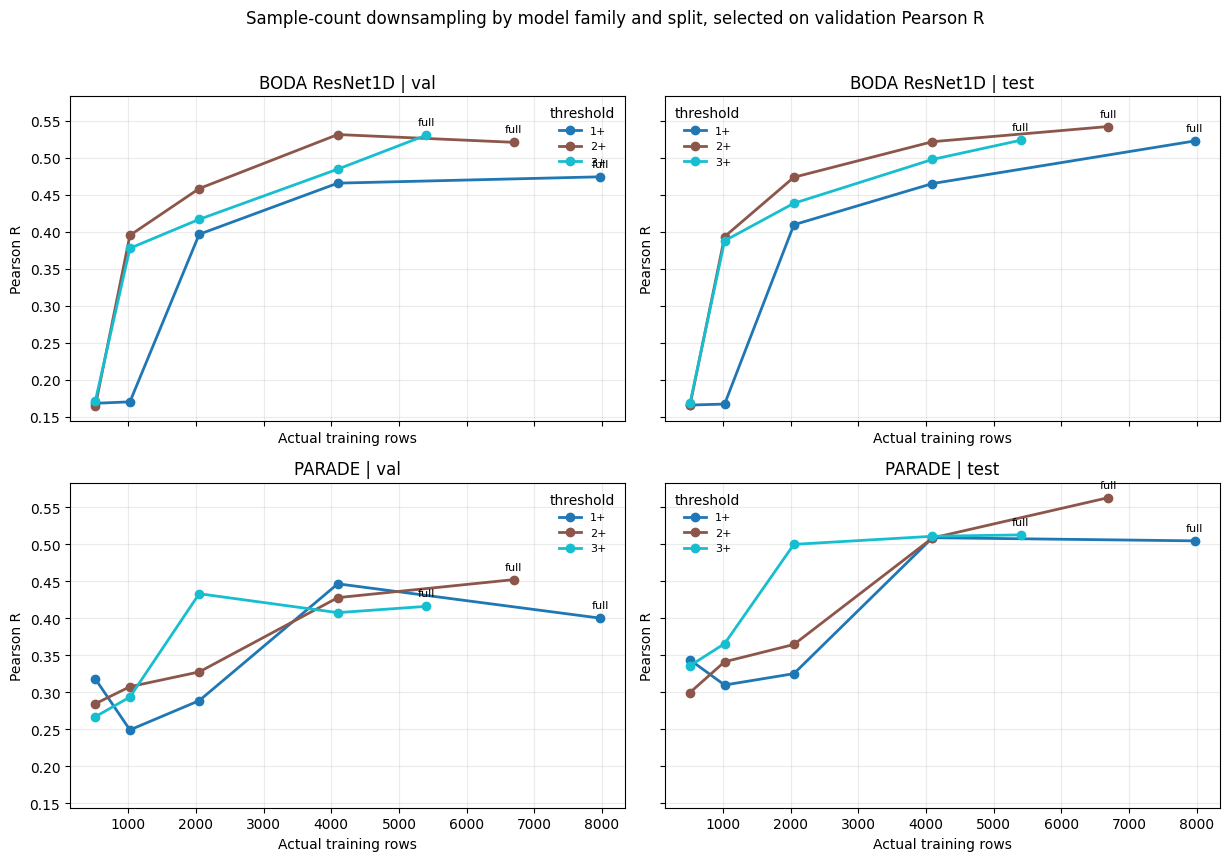

### Full-size endpoints selected separately by Pearson R, COD R2, and MSE loss

,selection_metric,model_family,train_threshold,cell_head,unfreeze_scope,actual_train_size,val_metric,test_metric,best_epoch
0,Pearson R,boda_resnet1d,1,c4,full,7972.0,0.47429,0.52275,54.0
1,Pearson R,boda_resnet1d,2,c4,full,6693.0,0.52091,0.54224,75.0
2,Pearson R,boda_resnet1d,3,c4,full,5402.0,0.53057,0.52377,109.0
3,Pearson R,parade,1,c4,full,7972.0,0.40033,0.50472,52.0
4,Pearson R,parade,2,c6,full,6693.0,0.45232,0.56307,119.0
5,Pearson R,parade,3,c6,full,5402.0,0.41624,0.51278,50.0
6,COD R2,boda_resnet1d,1,c4,full,7972.0,0.17820,0.26516,54.0
7,COD R2,boda_resnet1d,2,c4,full,6693.0,0.24040,0.28750,75.0
8,COD R2,boda_resnet1d,3,c4,full,5402.0,0.21700,0.25103,109.0
9,COD R2,parade,1,c4,full,7972.0,0.03483,0.15476,52.0


In [14]:
downsample_curve = plot_downsample_best_curve_facets(METRIC, include_thresholds=[1, 2, 3])

# If you still want the old all-in-one overlay, run:
# plot_downsample_best_curve_overlay(METRIC)

display(Markdown("### Full-size endpoints selected separately by Pearson R, COD R2, and MSE loss"))
display(downsample_metric_endpoint_table(("pearson", "cod_r2", "mse_loss")).round(5))

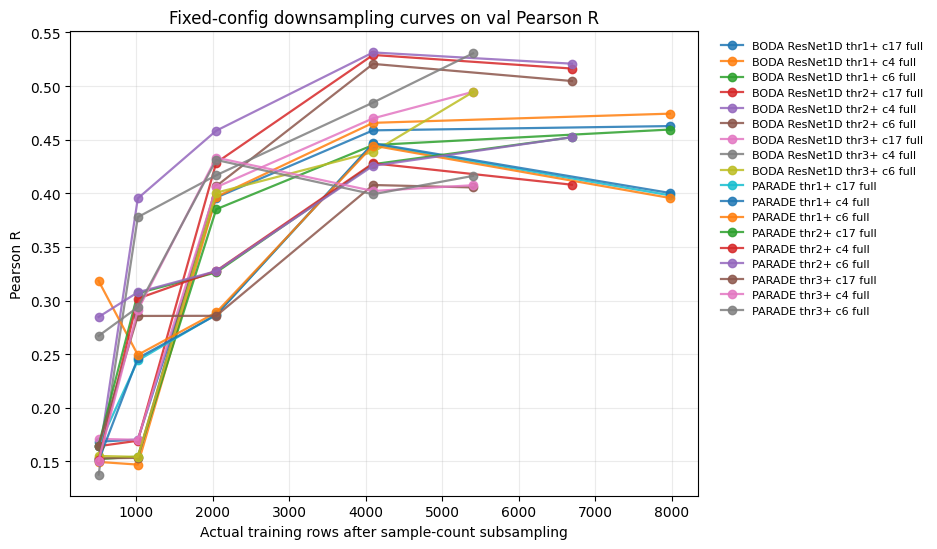

In [15]:
# Optional diagnostic: fixed-configuration curves, useful for seeing whether one head/scope is consistently better.
# Try changing the metric or filters, for example:
# plot_downsample_fixed_curves("cod_r2", score_split="test", model_family="parade", train_threshold=2)

fixed_curve_rows = plot_downsample_fixed_curves(METRIC, score_split="val")

## Optional next follow-ups

The notebook now includes analysis for the completed downsampling follow-up. The current downsampling run contains thresholds `2+` and `3+`, but not `1+`.

To append a matching `1+` downsampling curve into the same output root and refresh `combined/`, run:

```bash
cd /home/minhang/synBio_AL/boda2_EU

OUTDIR="/home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/inhouse_utr5_parade_resnet_downsample_top_configs_jun2026" \
GPU_IDS="0 1 2 3" \
MODEL_FAMILIES="boda_resnet1d parade" \
TRAIN_THRESHOLDS="1" \
CELL_HEADS="c4 c6 c17" \
UNFREEZE_SCOPES="full" \
TRAIN_SIZES="512 1024 2048 4096 full" \
HELDOUT_FRAC_WITHIN_HQ=0.20 \
HELDOUT_VAL_FRAC=0.20 \
bash src/finetune/finetune_sweep_scripts/hani_lib1_in_house_lib1_5Prime/run_inhouse_utr5_parade_resnet_small_hpo_parallel.sh
```

This uses the same cell-head search space as the completed downsampling run. If you also want to include the previous PARADE `c2` candidate for threshold `1+`, change `CELL_HEADS` to `"c2 c4 c6 c17"`; that gives threshold `1+` a broader head search space than thresholds `2+` and `3+`.

For a more robust learning-curve estimate later, the next useful expansion would be multiple seeds for the best few configs, because these runs still use one split seed and a small validation set (`72` rows).